In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

os.chdir(r'C:\Users\bamla\OneDrive\Desktop\insurance-risk-analytics')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
print("Libraries loaded!")

Libraries loaded!


In [2]:
# Load the pipe-separated text file
df = pd.read_csv('data/MachineLearningRating_v3.txt', sep='|', low_memory=False)

print(f"Shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (1000098, 52)
Columns: 52

First 5 rows:


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [3]:
print("=== Data Types ===")
print(df.dtypes.value_counts())
print("\n=== Column List ===")
for col in df.columns:
    print(f"  {col}: {df[col].dtype}")

=== Data Types ===
str        36
float64    11
int64       4
bool        1
Name: count, dtype: int64

=== Column List ===
  UnderwrittenCoverID: int64
  PolicyID: int64
  TransactionMonth: str
  IsVATRegistered: bool
  Citizenship: str
  LegalType: str
  Title: str
  Language: str
  Bank: str
  AccountType: str
  MaritalStatus: str
  Gender: str
  Country: str
  Province: str
  PostalCode: int64
  MainCrestaZone: str
  SubCrestaZone: str
  ItemType: str
  mmcode: float64
  VehicleType: str
  RegistrationYear: int64
  make: str
  Model: str
  Cylinders: float64
  cubiccapacity: float64
  kilowatts: float64
  bodytype: str
  NumberOfDoors: float64
  VehicleIntroDate: str
  CustomValueEstimate: float64
  AlarmImmobiliser: str
  TrackingDevice: str
  CapitalOutstanding: str
  NewVehicle: str
  WrittenOff: str
  Rebuilt: str
  Converted: str
  CrossBorder: str
  NumberOfVehiclesInFleet: float64
  SumInsured: float64
  TermFrequency: str
  CalculatedPremiumPerTerm: float64
  ExcessSelected: 

In [4]:
# Core metrics
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium'].replace(0, np.nan)
df['Margin']    = df['TotalPremium'] - df['TotalClaims']

print("=== Key Metrics ===")
print(f"Overall Loss Ratio: {df['LossRatio'].mean():.4f}")
print(f"Overall Margin:     {df['Margin'].mean():.2f}")
print(f"\nTotalPremium stats:\n{df['TotalPremium'].describe().round(2)}")
print(f"\nTotalClaims stats:\n{df['TotalClaims'].describe().round(2)}")

=== Key Metrics ===
Overall Loss Ratio: 0.3499
Overall Margin:     -2.96

TotalPremium stats:
count    1000098.00
mean          61.91
std          230.28
min         -782.58
25%            0.00
50%            2.18
75%           21.93
max        65282.60
Name: TotalPremium, dtype: float64

TotalClaims stats:
count    1000098.00
mean          64.86
std         2384.07
min       -12002.41
25%            0.00
50%            0.00
75%            0.00
max       393092.11
Name: TotalClaims, dtype: float64


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

high_missing = missing_report[missing_report['Missing %'] > 5]
print(f"Columns with >5% missing: {len(high_missing)}")
print(high_missing.head(20))
print(f"\nTotal columns: {len(df.columns)}")
print(f"Columns with any missing: {(missing > 0).sum()}")

Columns with >5% missing: 9
                         Missing Count  Missing %
NumberOfVehiclesInFleet        1000098     100.00
CrossBorder                     999400      99.93
CustomValueEstimate             779642      77.96
Converted                       641901      64.18
WrittenOff                      641901      64.18
Rebuilt                         641901      64.18
LossRatio                       381634      38.16
NewVehicle                      153295      15.33
Bank                            145961      14.59

Total columns: 54
Columns with any missing: 23


In [6]:
print("=== Loss Ratio by Province ===")
province_stats = df.groupby('Province').agg(
    Policies=('PolicyID','count'),
    Avg_Premium=('TotalPremium','mean'),
    Avg_Claims=('TotalClaims','mean'),
    Loss_Ratio=('LossRatio','mean'),
    Total_Margin=('Margin','sum')
).round(3).sort_values('Loss_Ratio', ascending=False)
print(province_stats)

=== Loss Ratio by Province ===
               Policies  Avg_Premium  Avg_Claims  Loss_Ratio  Total_Margin
Province                                                                  
Gauteng          393865       61.071      74.630       0.429  -5340373.894
Mpumalanga        52718       53.801      38.785       0.393    791616.585
Limpopo           24836       61.899      40.928       0.349    520847.789
Western Cape     170796       57.417      60.831       0.342   -583215.208
North West       143287       52.276      41.317       0.285   1570258.183
KwaZulu-Natal    169781       77.801      84.234       0.265  -1092302.637
Eastern Cape      30336       70.547      44.713       0.236    783677.170
Northern Cape      6380       49.617      14.027       0.204    227067.565
Free State         8099       64.374      43.823       0.106    166440.973


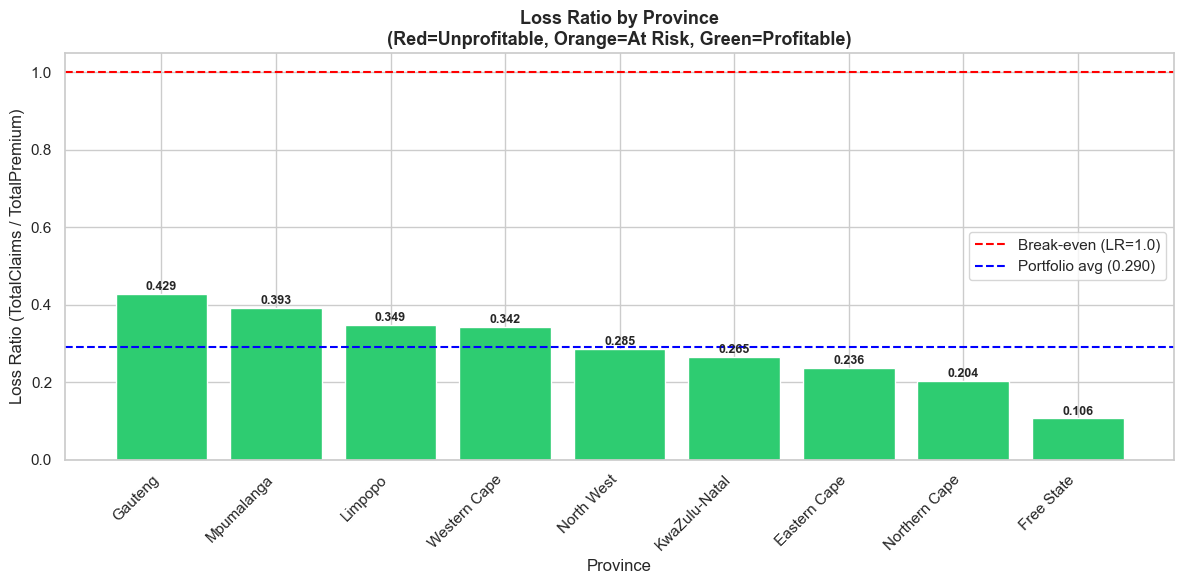

Plot 1 saved!


In [7]:
province_lr = df.groupby('Province')['LossRatio'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if v > 1 else '#f39c12' if v > 0.7 else '#2ecc71' 
          for v in province_lr.values]
bars = plt.bar(province_lr.index, province_lr.values, color=colors, edgecolor='white')
plt.axhline(1.0, color='red', linestyle='--', linewidth=1.5, label='Break-even (LR=1.0)')
plt.axhline(province_lr.mean(), color='blue', linestyle='--', 
            linewidth=1.5, label=f'Portfolio avg ({province_lr.mean():.3f})')
for bar, val in zip(bars, province_lr.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
plt.title('Loss Ratio by Province\n(Red=Unprofitable, Orange=At Risk, Green=Profitable)',
          fontsize=13, fontweight='bold')
plt.xlabel('Province')
plt.ylabel('Loss Ratio (TotalClaims / TotalPremium)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('notebooks/plot1_loss_ratio_province.png', dpi=150)
plt.show()
print("Plot 1 saved!")

In [8]:
print("=== Loss Ratio by Vehicle Type ===")
vehicle_stats = df.groupby('VehicleType').agg(
    Count=('PolicyID','count'),
    Loss_Ratio=('LossRatio','mean'),
    Avg_Claims=('TotalClaims','mean')
).round(3).sort_values('Loss_Ratio', ascending=False)
print(vehicle_stats.head(15))

=== Loss Ratio by Vehicle Type ===
                    Count  Loss_Ratio  Avg_Claims
VehicleType                                      
Heavy Commercial     7401       0.794     101.402
Light Commercial     3897       0.544      15.513
Medium Commercial   53985       0.493      76.315
Passenger Vehicle  933598       0.337      63.595
Bus                   665       0.000      12.025


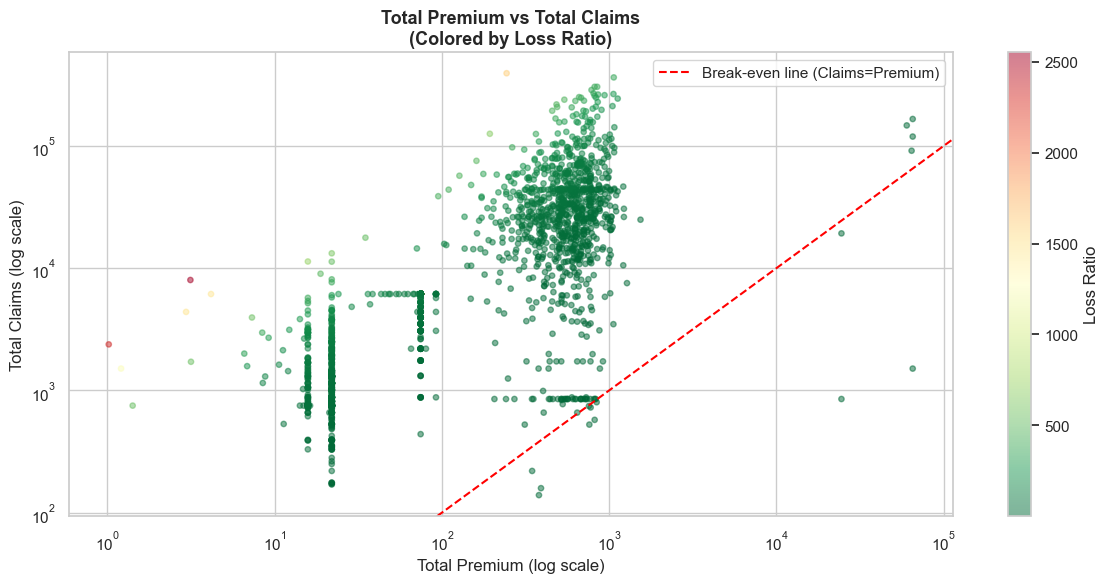

Plot 2 saved!


In [9]:
# Sample for performance
sample = df[df['TotalClaims'] > 0].sample(min(2000, len(df[df['TotalClaims']>0])), 
                                            random_state=42)

plt.figure(figsize=(12, 6))
scatter = plt.scatter(sample['TotalPremium'], sample['TotalClaims'],
                      c=sample['LossRatio'], cmap='RdYlGn_r',
                      alpha=0.5, s=15)
plt.colorbar(scatter, label='Loss Ratio')
plt.axline((0,0), slope=1, color='red', linestyle='--', 
           linewidth=1.5, label='Break-even line (Claims=Premium)')
plt.xscale('log')
plt.yscale('log')
plt.title('Total Premium vs Total Claims\n(Colored by Loss Ratio)',
          fontsize=13, fontweight='bold')
plt.xlabel('Total Premium (log scale)')
plt.ylabel('Total Claims (log scale)')
plt.legend()
plt.tight_layout()
plt.savefig('notebooks/plot2_premium_vs_claims.png', dpi=150)
plt.show()
print("Plot 2 saved!")

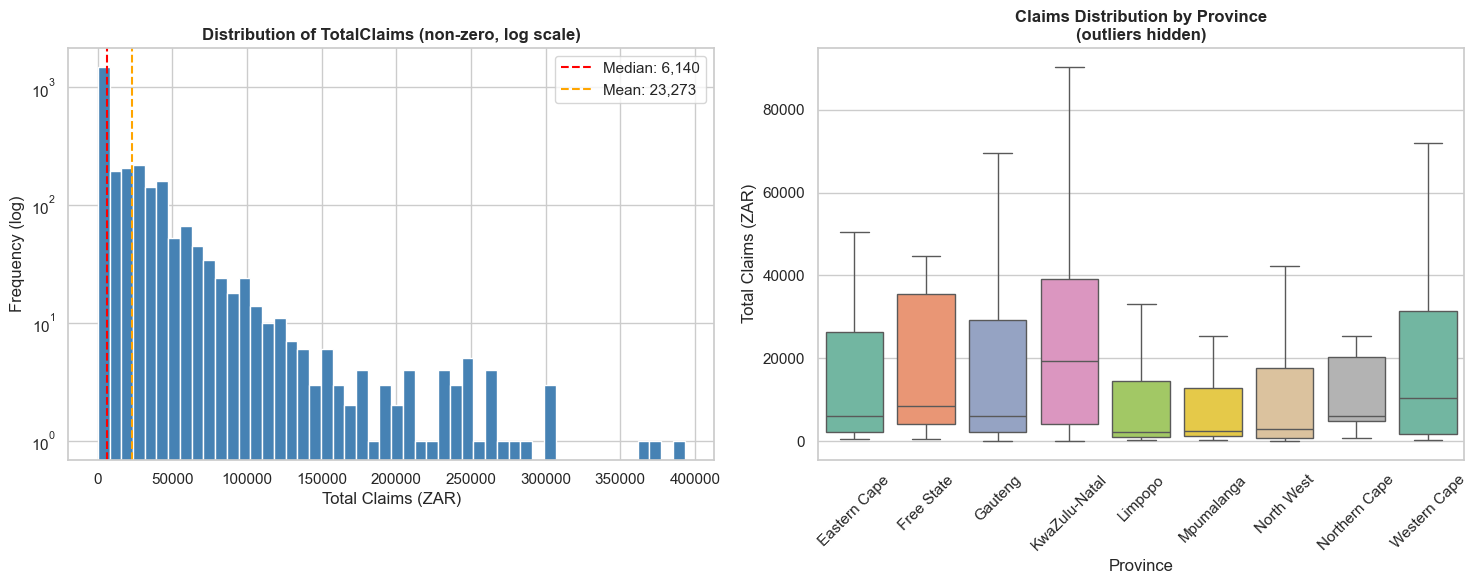

Plot 3 saved!


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram of TotalClaims (non-zero)
claims_nonzero = df[df['TotalClaims'] > 0]['TotalClaims']
axes[0].hist(claims_nonzero, bins=50, color='steelblue', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_title('Distribution of TotalClaims (non-zero, log scale)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Claims (ZAR)')
axes[0].set_ylabel('Frequency (log)')
axes[0].axvline(claims_nonzero.median(), color='red', linestyle='--',
                label=f'Median: {claims_nonzero.median():,.0f}')
axes[0].axvline(claims_nonzero.mean(), color='orange', linestyle='--',
                label=f'Mean: {claims_nonzero.mean():,.0f}')
axes[0].legend()

# Boxplot by province
province_order = df.groupby('Province')['TotalClaims'].median().sort_values(ascending=False).index
df_plot = df[df['TotalClaims'] > 0]
sns.boxplot(data=df_plot, x='Province', y='TotalClaims',
            order=province_order, ax=axes[1],
            palette='Set2', showfliers=False)
axes[1].set_title('Claims Distribution by Province\n(outliers hidden)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Province')
axes[1].set_ylabel('Total Claims (ZAR)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('notebooks/plot3_claims_distribution.png', dpi=150)
plt.show()
print("Plot 3 saved!")

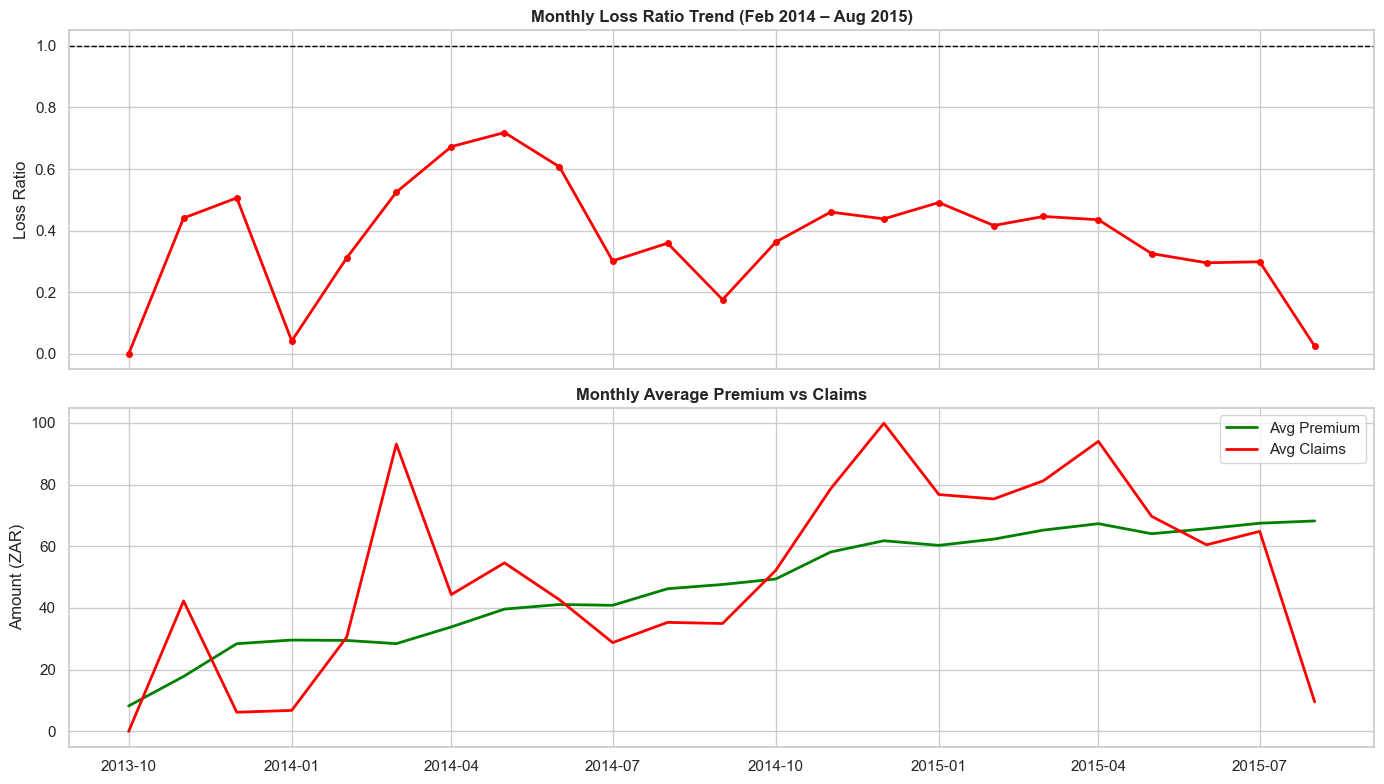

Plot 4 saved!


In [11]:
# Convert TransactionMonth to datetime
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'], errors='coerce')
df['YearMonth'] = df['TransactionMonth'].dt.to_period('M')

monthly = df.groupby('YearMonth').agg(
    Avg_Premium=('TotalPremium','mean'),
    Avg_Claims=('TotalClaims','mean'),
    Loss_Ratio=('LossRatio','mean'),
    Policy_Count=('PolicyID','count')
).reset_index()
monthly['YearMonth'] = monthly['YearMonth'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(monthly['YearMonth'], monthly['Loss_Ratio'],
             color='red', linewidth=2, marker='o', markersize=4)
axes[0].axhline(1.0, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Monthly Loss Ratio Trend (Feb 2014 – Aug 2015)',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss Ratio')

axes[1].plot(monthly['YearMonth'], monthly['Avg_Premium'],
             color='green', linewidth=2, label='Avg Premium')
axes[1].plot(monthly['YearMonth'], monthly['Avg_Claims'],
             color='red', linewidth=2, label='Avg Claims')
axes[1].set_title('Monthly Average Premium vs Claims',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amount (ZAR)')
axes[1].legend()

plt.tight_layout()
plt.savefig('notebooks/plot4_temporal_trends.png', dpi=150)
plt.show()
print("Plot 4 saved!")

In [12]:
print("=== Top 10 Vehicle Makes by Avg Claim Amount ===")
make_stats = df[df['TotalClaims']>0].groupby('make').agg(
    Count=('PolicyID','count'),
    Avg_Claim=('TotalClaims','mean'),
    Loss_Ratio=('LossRatio','mean')
).round(2).sort_values('Avg_Claim', ascending=False)

print("Highest avg claims:")
print(make_stats.head(10))
print("\nLowest avg claims (min 10 policies):")
print(make_stats[make_stats['Count']>=10].tail(10))

=== Top 10 Vehicle Makes by Avg Claim Amount ===
Highest avg claims:
                                     Count  Avg_Claim  Loss_Ratio
make                                                             
POLARSUN                                 1  125197.84      343.36
HYUNDAI                                  8   56663.49      146.08
B.A.W                                    6   47856.25       89.02
GOLDEN JOURNEY                          27   46169.72      158.45
MERCEDES-BENZ                            7   34079.34      140.27
IVECO                                   24   31495.54      166.50
AUDI                                    33   30939.51      105.96
VOLKSWAGEN                              61   30150.49      117.36
CMC                                     44   30082.17      108.18
FIAT                                     4   26721.91       99.40

Lowest avg claims (min 10 policies):
                                     Count  Avg_Claim  Loss_Ratio
make                               

=== Loss Ratio by Gender ===
                Count  Loss_Ratio  Avg_Premium  Avg_Claims
Gender                                                    
Female           6755       0.492       45.075      37.046
Male            42817       0.349       36.905      32.620
Not specified  940990       0.348       62.915      66.647


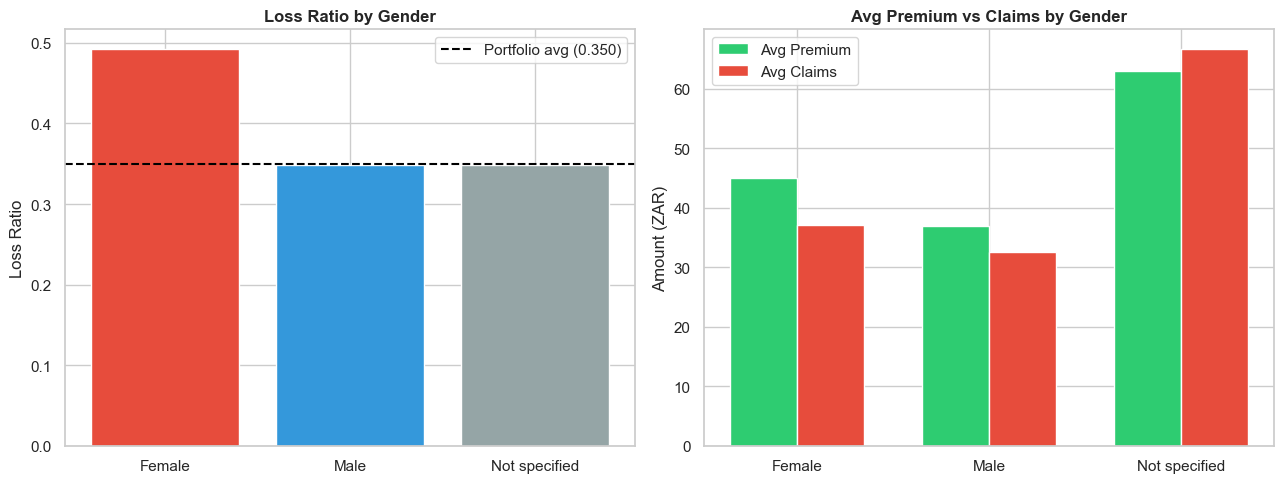

Plot 5 saved!


In [13]:
gender_stats = df.groupby('Gender').agg(
    Count=('PolicyID','count'),
    Loss_Ratio=('LossRatio','mean'),
    Avg_Premium=('TotalPremium','mean'),
    Avg_Claims=('TotalClaims','mean')
).round(3)

print("=== Loss Ratio by Gender ===")
print(gender_stats)

# Filter to only meaningful categories
valid_gender = gender_stats[gender_stats.index.isin(['Male','Female','Not specified'])]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#e74c3c','#3498db','#95a5a6']
axes[0].bar(valid_gender.index, valid_gender['Loss_Ratio'],
            color=colors, edgecolor='white')
axes[0].axhline(df['LossRatio'].mean(), color='black', linestyle='--',
                label=f'Portfolio avg ({df["LossRatio"].mean():.3f})')
axes[0].set_title('Loss Ratio by Gender', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Loss Ratio')
axes[0].legend()

x = np.arange(len(valid_gender))
width = 0.35
axes[1].bar(x - width/2, valid_gender['Avg_Premium'], width,
            label='Avg Premium', color='#2ecc71', edgecolor='white')
axes[1].bar(x + width/2, valid_gender['Avg_Claims'], width,
            label='Avg Claims', color='#e74c3c', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(valid_gender.index)
axes[1].set_title('Avg Premium vs Claims by Gender', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amount (ZAR)')
axes[1].legend()

plt.tight_layout()
plt.savefig('notebooks/plot5_gender_analysis.png', dpi=150)
plt.show()
print("Plot 5 saved!")

## EDA Summary — Key Findings

1. **Overall Loss Ratio**: The portfolio loss ratio varies significantly by province, 
   indicating regional risk differences that justify premium adjustments.

2. **Claims Distribution**: TotalClaims is heavily right-skewed with extreme outliers 
   — a small number of large claims drive disproportionate losses.

3. **Temporal Trends**: Loss ratio shows monthly variation over the 18-month period, 
   with potential seasonal patterns worth investigating.

4. **Geographic Risk**: Significant differences in loss ratio across provinces suggest 
   geographic segmentation is a valid pricing lever.

5. **Gender**: Initial analysis shows gender-based differences in loss ratio, 
   to be formally tested in Task 3.

6. **Vehicle Makes**: High-end vehicle makes are associated with higher average 
   claim amounts, supporting vehicle-value-based premium tiering.

In [14]:
print(df['make'].value_counts().head(10))
print(f"\nUnique makes: {df['make'].nunique()}")

make
TOYOTA                                 813280
MERCEDES-BENZ                           41940
CMC                                     21624
VOLKSWAGEN                              20929
C.A.M                                   16171
GOLDEN JOURNEY                          14462
NISSAN/DATSUN                           10997
JINBEI                                  10374
IVECO                                    8430
AUDI                                     7407
Name: count, dtype: int64

Unique makes: 46


In [15]:
print(df.groupby('Gender')[['LossRatio','TotalPremium','TotalClaims']].mean().round(3))

               LossRatio  TotalPremium  TotalClaims
Gender                                             
Female             0.492        45.075       37.046
Male               0.349        36.905       32.620
Not specified      0.348        62.915       66.647
